In [1]:
import numpy as np
import pandas as pd
import zarr
import os

path = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"

flow_path = os.path.join(path, "MTs_red_flow.zarr")
flow_array = zarr.open_array(flow_path, mode='r')

track_path = os.path.join(path, "beads_tracks.csv")
tracks = pd.read_csv(track_path)

In [49]:
single = tracks[tracks['particle'] == 1]
single

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
1,610.080017,1771.039309,146403.657000,23.411215,0.039700,66.937254,1677296.0,NaN,0,1
6,609.937689,1772.355790,145569.890510,23.429282,0.047680,65.400205,1689209.0,NaN,1,1
9,613.855914,1772.622064,153603.322073,23.752185,0.050335,68.511561,1710935.0,NaN,2,1
14,616.929056,1768.000577,145499.729149,22.902191,0.027863,64.661072,1727771.0,NaN,3,1
17,617.071914,1766.634349,147989.195851,23.547154,0.064988,66.854126,1712167.0,NaN,4,1
...,...,...,...,...,...,...,...,...,...,...
3989,533.360919,1328.251485,168540.293010,24.008637,0.093105,71.750736,1703191.0,NaN,997,1
3993,533.492614,1328.224684,179026.551364,23.470097,0.057823,73.683788,1679794.0,NaN,998,1
3997,538.182122,1326.685740,174373.431373,22.625459,0.053536,74.882353,1674842.0,NaN,999,1
4001,534.352245,1330.154182,168223.165983,23.606021,0.083527,70.780770,1706050.0,NaN,1000,1


In [ ]:
from tqdm import tqdm

scale = 0.11

height = 10/scale
weight = 10/scale

def local_polar(single, flow_array, height, weight):
    Ps = []

    h2 = int(height / 2)
    w2 = int(weight / 2)

    for t, group in tqdm(single.groupby('frame')):
        x = int(group['x'].values)
        y = int(group['y'].values)
        local_flow = flow_array[t, y-h2:y+h2, x-w2:x+w2]

        xf = local_flow[:,:,0]  # x成分
        yf = local_flow[:,:,1]  # y成分
        # ベクトルの大きさを計算
        magnitude = np.sqrt(xf**2 + yf**2)

        # --- 1. Polar Order Parameter (P) の計算 ---
        # 全ベクトルの平均を計算
        mean_xf = np.mean(xf, axis=(0,1))
        mean_yf = np.mean(yf, axis=(0,1))

        # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
        # P = |<v>| / <|v|>
        mean_magnitude_of_vectors = np.mean(magnitude, axis=(0,1))
        magnitude_of_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)

        P = magnitude_of_mean_vector / mean_magnitude_of_vectors
        Ps.append(P)

        #n_nanind = np.where(~np.isnan(P))
        #PNan = P[n_nanind[0]]

    Ps = np.array(Ps)
    Ps_nanind = np.where(~np.isnan(Ps))
    Ps_clean = Ps[Ps_nanind[0]]

    return Ps_clean

  0%|          | 0/1002 [00:00<?, ?it/s]/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_56091/51955525.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = int(group['x'].values)
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_56091/51955525.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = int(group['y'].values)
  1%|          | 12/1002 [00:05<06:54,  2.39it/s]/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_56091/51955525.py:35: RuntimeWarning: invalid value encountered in scalar divide
  P = magnitude_of_mean_vector / mean_magnitude_of_vectors
100%|██████████| 1002/1002 [06:50<00:00,  2.44it/s

(array([ 6., 26., 37., 44., 51., 47., 60., 73., 61., 64., 59., 46., 52.,
        62., 45., 42., 28., 39., 32., 23., 14., 12., 13.,  7.,  7.,  2.,
         2.,  5.,  0.,  1.]),
 array([0.00809583, 0.03396773, 0.05983961, 0.08571151, 0.1115834 ,
        0.13745528, 0.16332717, 0.18919906, 0.21507095, 0.24094284,
        0.26681474, 0.29268661, 0.31855851, 0.34443039, 0.37030229,
        0.39617416, 0.42204607, 0.44791797, 0.47378984, 0.49966174,
        0.52553368, 0.55140555, 0.57727742, 0.60314929, 0.62902123,
        0.6548931 , 0.68076497, 0.70663691, 0.73250878, 0.75838065,
        0.78425252]),
 <BarContainer object of 30 artists>)

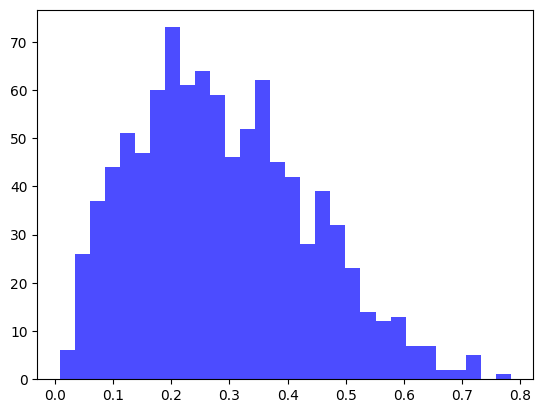

In [39]:
import matplotlib.pyplot as plt

plt.hist(Ps_clean, bins=30, color='blue', alpha=0.7)

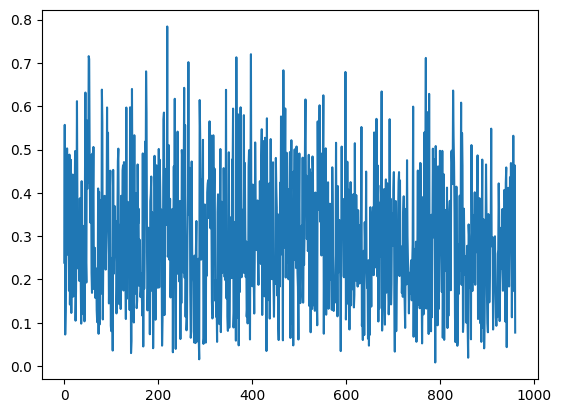

In [40]:
plt.plot(Ps_clean)

In [53]:
def local_polar(single, flow_array, height, weight):
    Ps = []

    h2 = int(height / 2)
    w2 = int(weight / 2)

    for t, group in single.groupby('frame'):
        x = int(group['x'].values)
        y = int(group['y'].values)
        local_flow = flow_array[t, y-h2:y+h2, x-w2:x+w2]

        xf = local_flow[:,:,0]  # x成分
        yf = local_flow[:,:,1]  # y成分
        # ベクトルの大きさを計算
        magnitude = np.sqrt(xf**2 + yf**2)

        # --- 1. Polar Order Parameter (P) の計算 ---
        # 全ベクトルの平均を計算
        mean_xf = np.mean(xf, axis=(0,1))
        mean_yf = np.mean(yf, axis=(0,1))

        # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
        # P = |<v>| / <|v|>
        mean_magnitude_of_vectors = np.mean(magnitude, axis=(0,1))
        magnitude_of_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)

        P = magnitude_of_mean_vector / mean_magnitude_of_vectors
        single['local_P'] = P

        #n_nanind = np.where(~np.isnan(P))
        #PNan = P[n_nanind[0]]

    Ps = np.array(Ps)

    single['local_P'] = Ps

    return Ps

In [ ]:
def local_polar(tracks, flow_array, height, weight):
    Ps = []

    h2 = int(height / 2)
    w2 = int(weight / 2)

    for t, group in tracks.groupby('frame'):
        x = int(group['x'].values)
        y = int(group['y'].values)
        local_flow = flow_array[t, y-h2:y+h2, x-w2:x+w2]

        xf = local_flow[:,:,0]  # x成分
        yf = local_flow[:,:,1]  # y成分
        # ベクトルの大きさを計算
        magnitude = np.sqrt(xf**2 + yf**2)

        # --- 1. Polar Order Parameter (P) の計算 ---
        # 全ベクトルの平均を計算
        mean_xf = np.mean(xf, axis=(0,1))
        mean_yf = np.mean(yf, axis=(0,1))

        # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
        # P = |<v>| / <|v|>
        mean_magnitude_of_vectors = np.mean(magnitude, axis=(0,1))
        magnitude_of_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)

        P = magnitude_of_mean_vector / mean_magnitude_of_vectors
        single['local_P'] = P

        #n_nanind = np.where(~np.isnan(P))
        #PNan = P[n_nanind[0]]

    Ps = np.array(Ps)

    single['local_P'] = Ps

    return Ps

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_56091/243035286.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single['local_P'] = Ps


In [ ]:
def getP(flow_array):
    
    x = flow_array[:, :, :, 0]  # x成分
    y = flow_array[:, :, :, 1]  # y成分
    # ベクトルの大きさを計算
    magnitude = np.sqrt(x**2 + y**2)

    # --- 1. Polar Order Parameter (P) の計算 ---
    # 全ベクトルの平均を計算
    mean_x = np.mean(x, axis=(1,2))
    mean_y = np.mean(y, axis=(1,2))
        
    # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
    # P = |<v>| / <|v|>
    mean_magnitude_of_vectors = np.mean(magnitude, axis=(1,2))
    magnitude_of_mean_vector = np.sqrt(mean_x**2 + mean_y**2)

    P = magnitude_of_mean_vector / mean_magnitude_of_vectors
    n_nanind = np.where(~np.isnan(P))
    PNan = P[n_nanind[0]]

    polar_path = os.path.join(path, "MTs_red_polar.zarr")
    Polar_parameter = zarr.open(polar_path, mode = 'w', shape = P.shape, dtype = P.dtype)
    Polar_parameter[:] = PNan

    return PNan

In [101]:
import numpy as np

# --- パラメータ設定 ---
# scale, height, weight は定義済みとします
h2 = int(height / 2)
w2 = int(weight / 2)

# --- 1. データの準備（ここが重要） ---
# 座標は uint8 ではなく int32 か int64 を使用（255を超えても大丈夫なように）
# tracksのインデックス順序を保証するため numpy array化
xc_all = tracks['x'].to_numpy().astype(np.int16)
yc_all = tracks['y'].to_numpy().astype(np.int16)
frames_all = tracks['frame'].to_numpy().astype(np.int16)

# 画像サイズ（境界チェック用）
max_h, max_w = flow_array.shape[1], flow_array.shape[2]

# --- 2. グリッドの作成（ベクトル化のキモ） ---
# ウィンドウ内の相対座標を作成 (-w2 ～ +w2, -h2 ～ +h2)
dy = np.arange(-h2, h2)
dx = np.arange(-w2, w2)

# メッシュグリッドを作成 (ウィンドウの大きさ分のオフセット)
# shape: (window_h, window_w)
grid_y, grid_x = np.meshgrid(dy, dx, indexing='ij')

# --- 3. 全座標へのブロードキャスト ---
# 全ての点の中心座標に、オフセットを足し合わせる
# xc_all[:, None, None] は (N, 1, 1)
# grid_x[None, :, :]    は (1, window_h, window_w)
# これらを足すと (N, window_h, window_w) の巨大な座標配列ができる
all_indices_y = yc_all[:, None, None] + grid_y[None, :, :]
all_indices_x = xc_all[:, None, None] + grid_x[None, :, :]

# --- 4. 境界クリッピング（エラー回避） ---
# 画像範囲外を参照しないようにクリップする
# ※端のピクセルの扱いを厳密にする場合は別途マスク処理が必要ですが、
#   ここでは高速化優先で最近傍の画素を複製する挙動（clip）にします。
all_indices_y = np.clip(all_indices_y, 0, max_h - 1)
all_indices_x = np.clip(all_indices_x, 0, max_w - 1)

# --- 5. 一括データ抽出（ファンシーインデックス） ---
# flow_arrayから一気にデータを抜きます
# 結果のshape: (N_tracks, window_h, window_w, 2)
# frames_all[:, None, None] でフレーム次元も合わせます
batch_flows = flow_array[frames_all[:, None, None], all_indices_y, all_indices_x]

# --- 6. 行列計算 (Batch Processing) ---
# 成分分解
batch_xf = batch_flows[..., 0] # shape: (N, h, w)
batch_yf = batch_flows[..., 1] # shape: (N, h, w)

# 各画素の大きさ
magnitude = np.sqrt(batch_xf**2 + batch_yf**2)

# 平均計算 (axis=(1, 2) はウィンドウの縦横方向をつぶして平均をとる)
# 結果のshape: (N_tracks, )
mean_xf = np.mean(batch_xf, axis=(1, 2))
mean_yf = np.mean(batch_yf, axis=(1, 2))
mean_magnitude_of_vectors = np.mean(magnitude, axis=(1, 2))

# 平均ベクトルの大きさ
magnitude_of_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)

# Polar Order Parameter (P)
# ゼロ除算回避
with np.errstate(divide='ignore', invalid='ignore'):
    Ps = magnitude_of_mean_vector / mean_magnitude_of_vectors
    # 全て0だった場合などはNaNになるので0またはNaNで埋める
    Ps = np.nan_to_num(Ps, nan=0.0)

print(f"Calculated {len(Ps)} points instantly.")

IndexError: unsupported selection item for basic indexing; expected integer or slice, got <class 'numpy.ndarray'>

In [ ]:
import numpy as np
from tqdm import tqdm

# --- パラメータ設定 ---
h2 = int(height / 2)
w2 = int(weight / 2)

# トラックデータをNumpy配列化
xc_all = tracks['x'].to_numpy().astype(np.int32)
yc_all = tracks['y'].to_numpy().astype(np.int32)
frames_all = tracks['frame'].to_numpy().astype(np.int32)

# 結果を格納する配列（最初はNaNで埋めておく）
Ps = np.full(len(tracks), np.nan)

# グリッドの作成（相対座標）
dy = np.arange(-h2, h2)
dx = np.arange(-w2, w2)
grid_y, grid_x = np.meshgrid(dy, dx, indexing='ij')

# 画像サイズ取得（flow_arrayがリストの場合は最初の要素から形状を取得）
if isinstance(flow_array, list):
    max_h, max_w = flow_array[0].shape[0], flow_array[0].shape[1]
else:
    max_h, max_w = flow_array.shape[1], flow_array.shape[2]

# --- フレームごとの高速ループ ---
# ユニークなフレーム番号を取得してループ
unique_frames = np.unique(frames_all)

print(f"Processing {len(unique_frames)} frames...")

for t in tqdm(unique_frames):
    # 1. このフレームにある点のインデックスを全て取得（ブールマスク）
    mask = (frames_all == t)
    
    # 該当する点の座標を抽出
    xs_t = xc_all[mask]
    ys_t = yc_all[mask]
    
    # 該当する点がなければスキップ
    if len(xs_t) == 0:
        continue

    # 2. 現在のフレーム画像を取得（ここがリストやh5pyでも動く理由）
    # flow_array全体を配列アクセスせず、t番目だけを取り出すのでエラーにならない
    current_flow = flow_array[t] 
    
    # 3. 座標計算（ブロードキャスト）
    # (N_points, window_h, window_w) のインデックスを作成
    idx_y = ys_t[:, None, None] + grid_y[None, :, :]
    idx_x = xs_t[:, None, None] + grid_x[None, :, :]
    
    # 境界クリップ
    idx_y = np.clip(idx_y, 0, max_h - 1)
    idx_x = np.clip(idx_x, 0, max_w - 1)
    
    # 4. ファンシーインデックスで一括抽出
    # current_flow は2次元(H,W,2)なので、単純な配列アクセスが可能
    batch_flows = current_flow[idx_y, idx_x] # shape: (N_points, h, w, 2)
    
    # 5. 行列計算（ここからは前回と同じ）
    batch_xf = batch_flows[..., 0]
    batch_yf = batch_flows[..., 1]
    
    magnitude = np.sqrt(batch_xf**2 + batch_yf**2)
    
    # 平均計算
    mean_xf = np.mean(batch_xf, axis=(1, 2))
    mean_yf = np.mean(batch_yf, axis=(1, 2))
    
    mean_mag_vectors = np.mean(magnitude, axis=(1, 2))
    mag_mean_vector = np.sqrt(mean_xf**2 + mean_yf**2)
    
    # 計算結果を代入（ゼロ除算対策付き）
    with np.errstate(divide='ignore', invalid='ignore'):
        P_vals = mag_mean_vector / mean_mag_vectors
    
    # NaNを0にするならここで（必要なければコメントアウト）
    #P_vals = np.nan_to_num(P_vals, nan=0.0)
    
    # 結果を元の配列の正しい位置に戻す
    Ps[mask] = P_vals

print("Calculation complete.")

Processing 1002 frames...


 40%|███▉      | 397/1002 [02:43<04:13,  2.39it/s]

In [ ]:
tracks['local_P'] = Ps